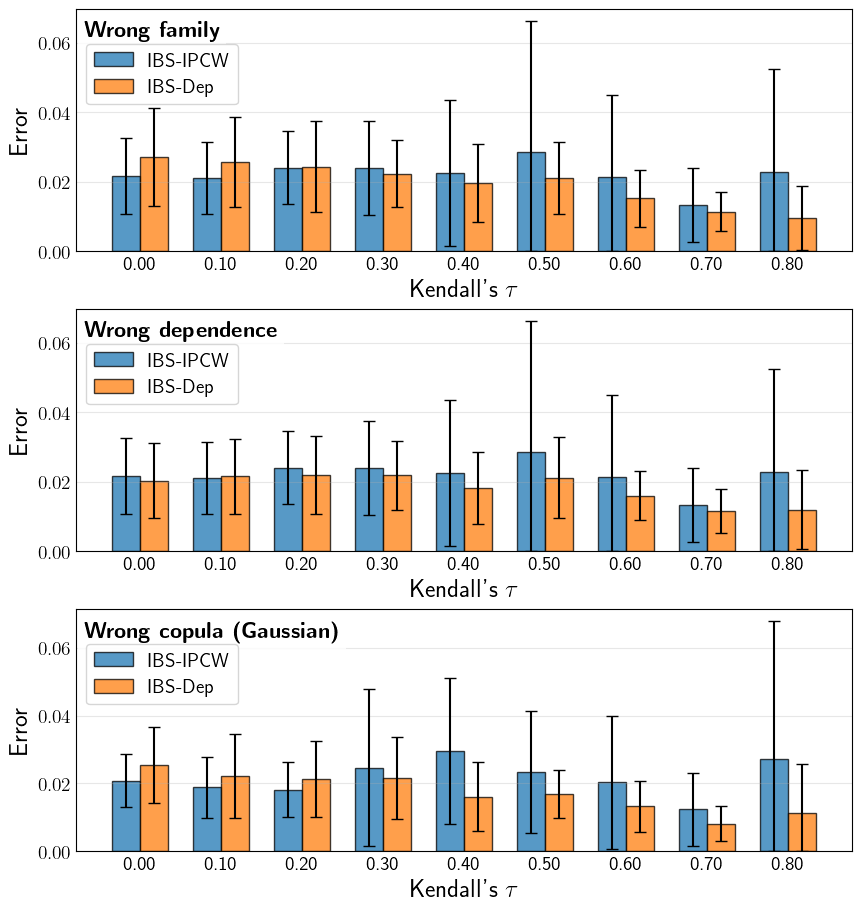

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 16,
    "font.size": 14.0,
    "legend.fontsize": 14,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

keep_exps = ["family", "dep", "gaussian"]
df = df[df["experiment"].isin(keep_exps)].copy()

# --- Optional mild outlier filtering ---
cols = ["err_ipcw", "err_dep_bguw"]
z = np.abs(zscore(df[cols], nan_policy="omit"))
df = df[(z < 3.0).all(axis=1)]

# --- Aggregate mean + std ---
group_cols = ["experiment", "k_tau"]
agg = (
    df.groupby(group_cols, as_index=False)
      .agg(
          ipcw_mean=("err_ipcw", "mean"),
          ipcw_std=("err_ipcw", "std"),
          dep_mean=("err_dep_bguw", "mean"),
          dep_std=("err_dep_bguw", "std"),
      )
      .sort_values(["experiment", "k_tau"])
)

for c in ["ipcw_std", "dep_std"]:
    agg[c] = agg[c].fillna(0.0)

exp_order = ["family", "dep", "gaussian"]

# --- Plot ---
fig, axs = plt.subplots(3, 1, figsize=(8.5, 9.0), constrained_layout=True)

bar_width = 0.35
color_ipcw = "C0"   # blue
color_dep  = "C1"   # orange

for i, exp in enumerate(exp_order):
    ax = axs[i]
    sub = agg[agg["experiment"] == exp].copy()

    taus = sub["k_tau"].values
    x = np.arange(len(taus))

    # --- Compute asymmetric error bars clipped at zero ---
    ipcw_lower = np.minimum(sub["ipcw_std"].values, sub["ipcw_mean"].values)
    dep_lower  = np.minimum(sub["dep_std"].values,  sub["dep_mean"].values)

    ipcw_yerr = np.vstack([ipcw_lower, sub["ipcw_std"].values])
    dep_yerr  = np.vstack([dep_lower,  sub["dep_std"].values])

    # IBS-IPCW
    ax.bar(
        x - bar_width / 2,
        sub["ipcw_mean"].values,
        bar_width,
        yerr=ipcw_yerr,
        capsize=4,
        color=color_ipcw,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-IPCW",
    )

    # IBS-Dep (CG, UW)
    ax.bar(
        x + bar_width / 2,
        sub["dep_mean"].values,
        bar_width,
        yerr=dep_yerr,
        capsize=4,
        color=color_dep,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-Dep",
    )
    
    label_map = {
    "family": r"\textbf{Wrong family}",
    "dep": r"\textbf{Wrong dependence}",
    "gaussian": r"\textbf{Wrong copula (Gaussian)}",
    }
    
    ax.text(
        0.01, 0.95,
        label_map[exp],
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(r"Kendall's $\tau$", fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(0, 0.895),
    )

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()